In [ ]:
import numpy as np

from pint.models import get_model_and_toas
from pint.config import examplefile
from pint.logging import setup as setup_log

from enterprise_wideband.pulsar import WidebandPulsar
from enterprise_wideband.signals import WidebandTimingModel, WidebandMeasurementNoise
from enterprise.signals.signal_base import PTA

from PTMCMCSampler.PTMCMCSampler import PTSampler
import corner

In [34]:
setup_log(level="WARNING")

3

In [35]:
parfile = examplefile("test-wb-0.par")
timfile = examplefile("test-wb-0.tim")
m, t = get_model_and_toas(parfile, timfile, planets=True)
psr = WidebandPulsar(t, m)

WARNING  (pint.models.model_builder     ): UNITS is not specified. Assuming TDB...


In [36]:
tm = WidebandTimingModel()
wn = WidebandMeasurementNoise()

In [37]:
model = tm + wn

pta = PTA([model(psr)])

In [38]:
x0 = np.array([p.sample() for p in pta.params])

In [42]:
# dimension of parameter space
ndim = len(x0)

# initial jump covariance matrix
cov = np.diag(np.ones(ndim) * 0.01**2)

# intialize sampler
sampler = PTSampler(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir="chains/")

In [44]:
N = 100000
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Finished 0.00 percent in 0.000337 s Acceptance rate = 0

WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/wideband-dev/lib/python3.12/site-packages/enterprise/signals/parameter.py:70 RuntimeWarning: divide by zero encountered in log


Finished 10.00 percent in 3.090153 s Acceptance rate = 0.61145Adding DE jump with weight 50
Finished 100.00 percent in 25.648991 s Acceptance rate = 0.52691
Run Complete


In [45]:
chain = np.loadtxt("chains/chain_1.txt")
burn = int(0.25 * chain.shape[0])

In [46]:
labels = [p[7:] for p in pta.param_names]

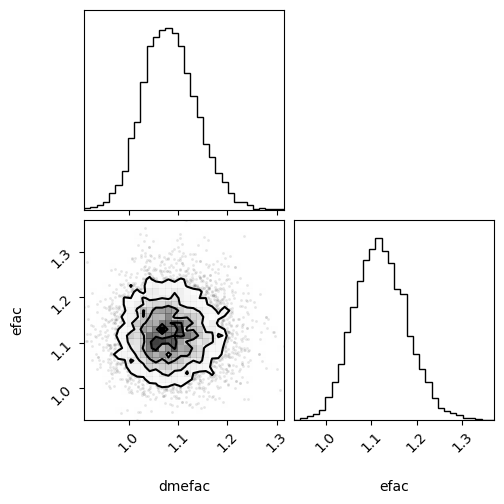

In [47]:
corner.corner(
    chain[burn:, :-4],
    bins=32,
    # truths=truths,
    labels=labels,
);